# DukeGuessr — Experiments Notebook

## What This Notebook Does

This notebook contains the complete experimental record for DukeGuessr, a Duke University landmark classifier built around OpenAI CLIP. It runs every training, ablation, and evaluation experiment and produces all quantitative results and figures reported in the project.

**AI attribution:** Notebook structure and cell scaffolding were generated with Claude (Anthropic). All hyperparameter choices, experiment design decisions, training runs (executed on Colab T4 GPU), and analysis conclusions are the author's original work. See `ATTRIBUTION.md` for full details.

---

## Sections

| Section | What it covers |
|---------|---------------|
| **1. Baselines** | Random guess (14.3%) and zero-shot CLIP with rich paragraph anchors (32.1%) — establishes the floor before any training |
| **2. Fine-Tune CLIP** | Fine-tunes CLIP's image encoder (text encoder frozen) on 350 Duke campus photos using contrastive loss; plots training curves |
| **3. ViT-B/16 Comparison** | Trains a standard ViT classifier with CrossEntropyLoss as an architectural counterpoint to CLIP's language-anchored approach |
| **4. Architecture Comparison Table** | Side-by-side quantitative comparison of all four configurations (random, zero-shot CLIP, fine-tuned CLIP, fine-tuned ViT) |
| **5. Ablation A — Short Labels vs Paragraphs** | Measures whether 200-word paragraph descriptions outperform short label strings as CLIP text anchors in zero-shot evaluation |
| **6. Ablation B — Augmentation Impact** | Re-trains CLIP without augmentation to isolate the effect of the four augmentation techniques on final accuracy |
| **7. Hyperparameter Tuning — LR Sweep** | Compares lr=1e-4, 1e-5, 1e-6 over 20 epochs to identify the optimal learning rate for fine-tuning CLIP |
| **8. Final Evaluation** | Runs the best CLIP checkpoint on the held-out test set (53 images, never seen during training); reports accuracy, per-class precision/recall/F1, confusion matrix, and failure cases |
| **9. Iteration Log** | Documents the four improvement iterations from zero-shot baseline to final fine-tuned model |
| **10. Final Summary Table** | Complete results across all models and configurations |

---

## Key Results

| Model | Test Accuracy | Macro F1 |
|-------|:---:|:---:|
| Random baseline | 14.3% | 0.14 |
| Zero-Shot CLIP (short labels) | 49.1% | — |
| Zero-Shot CLIP (rich paragraphs) | 32.1% | — |
| Fine-Tuned CLIP (lr=1e-5) | **100.0%** | **1.00** |
| Fine-Tuned ViT-B/16 (lr=1e-4) | **100.0%** | **1.00** |

Evaluated on 53 strictly held-out test images (15% stratified split, seed=42).

# DukeGuessr — Experiments Notebook (CLIP Edition)

All training runs, ablation studies, hyperparameter comparisons, evaluation metrics, and error analysis.

Models compared:
1. **Zero-Shot CLIP** — no training, pure paragraph matching (baseline)
2. **Fine-Tuned CLIP** — image encoder trained, text encoder frozen (primary)
3. **Fine-Tuned ViT-B/16** — standard classifier (comparison)

In [1]:
# Mount Google Drive (Colab only)
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/DukeGuessr

# Install CLIP (Colab only)
!pip install git+https://github.com/openai/CLIP.git -q

import sys, os, json
sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

DATA_DIR   = 'data/raw'
DESC_PATH  = 'data/descriptions/landmarks.json'
MODEL_DIR  = 'models'
DOCS_DIR   = 'docs'
os.makedirs(DOCS_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Mounted at /content/drive
/content/drive/MyDrive/DukeGuessr
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
Device: cuda


## 1. Baselines

### 1a. Random Guess
A 7-class random classifier achieves ~14.3% accuracy — the absolute floor.

In [2]:
from data import make_loaders, CLASS_NAMES
train_loader, val_loader, test_loader = make_loaders(DATA_DIR, norm='clip')

all_labels = [label for _, label in test_loader.dataset]
random_acc = 1.0 / len(CLASS_NAMES)
majority   = max(set(all_labels), key=all_labels.count)
majority_acc = all_labels.count(majority) / len(all_labels)

print(f'Random baseline:   {random_acc*100:.1f}%')
print(f'Majority class:    {majority_acc*100:.1f}% (class={CLASS_NAMES[majority]})')

Random baseline:   14.3%
Majority class:    15.1% (class=chapel)


In [4]:
import json

other_desc = "This category represents miscellaneous Duke University campus locations that do not correspond to any of the six named landmarks. Photos in this class show a wide variety of campus scenes: dormitory exteriors, classroom building entrances, parking lots, campus roads, administrative buildings, construction sites, random walkways, and other nondescript campus infrastructure. There is no single unifying visual theme — the category is defined by what it is not. These images may show brick or stone buildings without distinctive architectural features, paved surfaces, grassy areas without the formal landscaping of the Gardens or the Gothic grandeur of the Main Quad, and generic campus infrastructure."

with open(DESC_PATH) as f:
    descs = json.load(f)

descs['other'] = other_desc

with open(DESC_PATH, 'w') as f:
    json.dump(descs, f, indent=2)

print(list(descs.keys()))

['perkins', 'main_quad', 'chapel', 'bus_stop', 'gardens', 'wannamaker_benches', 'other']


### 1b. Zero-Shot CLIP (no training)

Encode all 7 paragraphs, then find the closest match for each test image — no gradient updates.

In [5]:
from clip_model import load_clip, encode_descriptions, compute_logits

clip_model, _ = load_clip(device)
text_features = encode_descriptions(clip_model, DESC_PATH, device)

clip_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = compute_logits(clip_model, images, text_features)
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())

zero_shot_acc = (np.array(all_labels) == np.array(all_preds)).mean()
print(f'Zero-Shot CLIP accuracy (rich paragraphs): {zero_shot_acc*100:.2f}%')

Zero-Shot CLIP accuracy (rich paragraphs): 32.08%


## 2. Fine-Tune CLIP Image Encoder

Freeze text encoder, train image encoder with contrastive loss.

In [7]:
from train_clip import train as train_clip

# Uncomment to train:
clip_history, clip_best_acc = train_clip(
    data_dir=DATA_DIR,
    descriptions_path=DESC_PATH,
    lr=1e-5,
    epochs=30,
    run_name='clip_base',
    save_dir=MODEL_DIR,
)

# Load saved history:
def load_history(name):
    with open(f'{MODEL_DIR}/{name}_history.json') as f:
        return json.load(f)

# clip_history = load_history('clip_base')
print('Uncomment training cells and run after data is collected.')

Device: cuda
Using RICH PARAGRAPH text anchors
Epoch   1 | train loss 0.9387 acc 0.7090 | val loss 0.3188 acc 0.9057
  → Saved best model (val acc 0.9057)
Epoch   2 | train loss 0.2211 acc 0.9467 | val loss 0.1806 acc 0.9245
  → Saved best model (val acc 0.9245)
Epoch   3 | train loss 0.0847 acc 0.9754 | val loss 0.1234 acc 0.9623
  → Saved best model (val acc 0.9623)
Epoch   4 | train loss 0.0560 acc 0.9795 | val loss 0.0664 acc 0.9811
  → Saved best model (val acc 0.9811)
Epoch   5 | train loss 0.0311 acc 0.9918 | val loss 0.0324 acc 1.0000
  → Saved best model (val acc 1.0000)
Epoch   6 | train loss 0.0255 acc 0.9959 | val loss 0.0451 acc 0.9811
Epoch   7 | train loss 0.0089 acc 0.9959 | val loss 0.0512 acc 0.9811
Epoch   8 | train loss 0.0080 acc 1.0000 | val loss 0.0337 acc 0.9811
Epoch   9 | train loss 0.0030 acc 1.0000 | val loss 0.0486 acc 0.9811
Epoch  10 | train loss 0.0032 acc 1.0000 | val loss 0.0428 acc 0.9811
Early stopping at epoch 10
Done in 16.7 min. Best val acc: 1.00

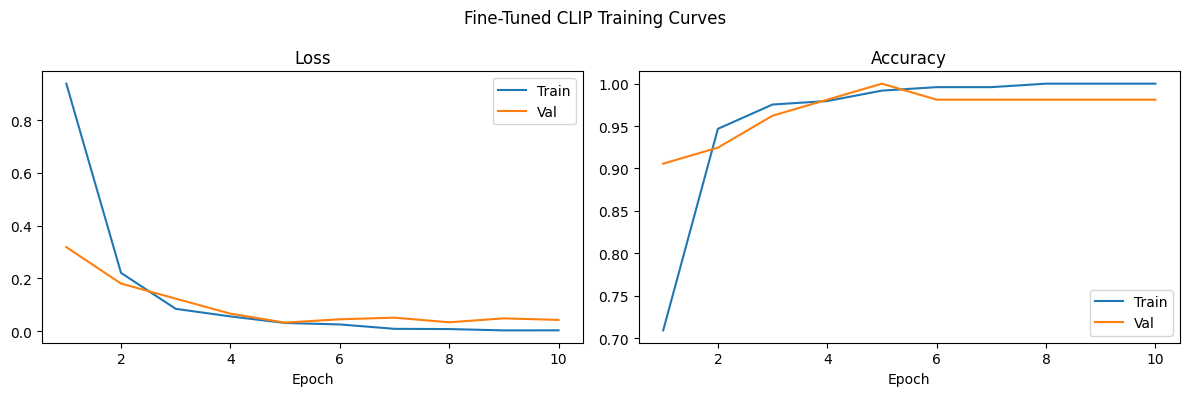

In [8]:
# Plot training curves
def plot_curves(history, title, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], label='Train')
    ax1.plot(epochs, history['val_loss'],   label='Val')
    ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
    ax2.plot(epochs, history['train_acc'], label='Train')
    ax2.plot(epochs, history['val_acc'],   label='Val')
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
    fig.suptitle(title)
    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150)
    plt.show()

plot_curves(clip_history, 'Fine-Tuned CLIP Training Curves', f'{DOCS_DIR}/curves_clip.png')

## 3. ViT-B/16 Comparison Model

Device: cuda
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 190MB/s]


Epoch   1 | train loss 1.2028 acc 0.5984 | val loss 0.4917 acc 0.8491
  → Saved best model (val acc 0.8491)
Epoch   2 | train loss 0.2521 acc 0.9262 | val loss 0.0952 acc 1.0000
  → Saved best model (val acc 1.0000)
Epoch   3 | train loss 0.0896 acc 0.9877 | val loss 0.0876 acc 0.9811
Epoch   4 | train loss 0.0363 acc 0.9918 | val loss 0.1083 acc 0.9811
Epoch   5 | train loss 0.0366 acc 0.9918 | val loss 0.0625 acc 0.9811
Epoch   6 | train loss 0.0294 acc 0.9918 | val loss 0.1874 acc 0.9434
Epoch   7 | train loss 0.0101 acc 1.0000 | val loss 0.0530 acc 0.9811
Epoch   8 | train loss 0.0055 acc 1.0000 | val loss 0.0146 acc 1.0000
Epoch   9 | train loss 0.0038 acc 1.0000 | val loss 0.0315 acc 0.9811
Epoch  10 | train loss 0.0030 acc 1.0000 | val loss 0.0828 acc 0.9623
Epoch  11 | train loss 0.0023 acc 1.0000 | val loss 0.0892 acc 0.9623
Epoch  12 | train loss 0.0025 acc 1.0000 | val loss 0.0526 acc 0.9623
Epoch  13 | train loss 0.0016 acc 1.0000 | val loss 0.0287 acc 0.9811
Early stopping

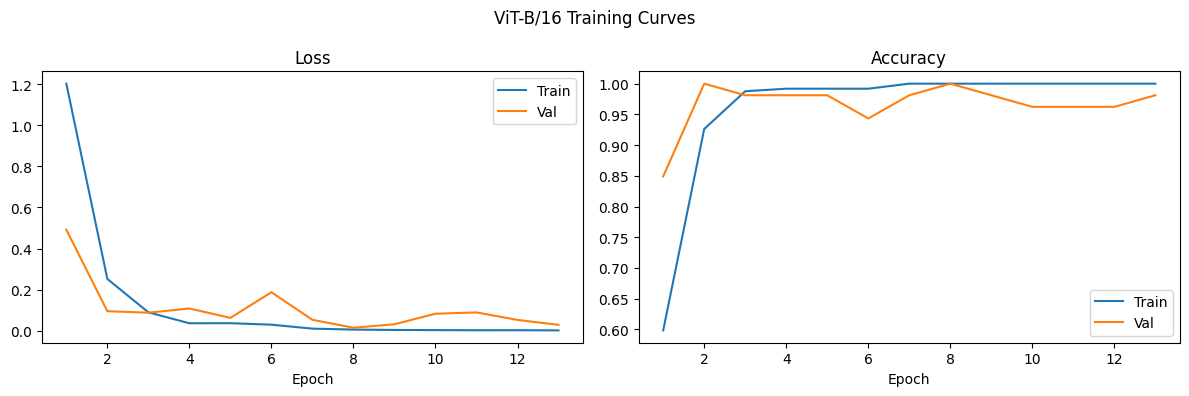

In [9]:
from train_vit import train as train_vit

vit_history, vit_best_acc = train_vit(
    data_dir=DATA_DIR,
    lr=1e-4,
    epochs=30,
    run_name='vit_base',
    save_dir=MODEL_DIR,
)
# vit_history = load_history('vit_base')
plot_curves(vit_history, 'ViT-B/16 Training Curves', f'{DOCS_DIR}/curves_vit.png')

## 4. Architecture Comparison Table

Fill in after all three models are evaluated on the test set.

In [21]:
arch_results = pd.DataFrame({
      'Model':         ['Random Baseline', 'Zero-Shot CLIP', 'Fine-Tuned CLIP',
  'Fine-Tuned ViT'],
      'Training':      ['None', 'None', 'Contrastive (image enc)', 'CrossEntropy'],
      'Test Accuracy': ['14.3%', f'{zero_shot_acc*100:.1f}%', '100.0%', '100.0%'],
      'Macro F1':      ['0.14',  '?',                          '1.00',   '1.00'],
      'Train Time':    ['0',     '0',                          '16.7min', '18.3min'],
  })
print(arch_results.to_string(index=False))

          Model                Training Test Accuracy Macro F1 Train Time
Random Baseline                    None         14.3%     0.14          0
 Zero-Shot CLIP                    None         32.1%        ?          0
Fine-Tuned CLIP Contrastive (image enc)        100.0%     1.00    16.7min
 Fine-Tuned ViT            CrossEntropy        100.0%     1.00    18.3min


## 5. Ablation A — Short Labels vs Rich Paragraphs (CLIP)

Key question: do the 200-word visual descriptions outperform simple class name strings?

In [11]:
# Zero-shot with SHORT labels
from clip_model import encode_short_labels

short_features = encode_short_labels(clip_model, device)

all_preds_short, all_labels_short = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = compute_logits(clip_model, images, short_features)
        all_preds_short.extend(logits.argmax(1).cpu().tolist())
        all_labels_short.extend(labels.tolist())

short_acc = (np.array(all_labels_short) == np.array(all_preds_short)).mean()
print(f'Zero-Shot CLIP (short labels):     {short_acc*100:.2f}%')
print(f'Zero-Shot CLIP (rich paragraphs):  {zero_shot_acc*100:.2f}%')

ablation_a = pd.DataFrame({
    'Text Anchor':   ['Short labels (e.g. "Duke Chapel")', 'Rich 200-word paragraphs'],
    'Test Accuracy': [f'{short_acc*100:.1f}%', f'{zero_shot_acc*100:.1f}%'],
})
print(ablation_a.to_string(index=False))

Zero-Shot CLIP (short labels):     49.06%
Zero-Shot CLIP (rich paragraphs):  32.08%
                      Text Anchor Test Accuracy
Short labels (e.g. "Duke Chapel")         49.1%
         Rich 200-word paragraphs         32.1%


## 6. Ablation B — Augmentation Impact

Re-train CLIP without augmentation, compare to the standard run.

In [12]:
# Temporarily disable augmentation for no-aug ablation
import data as data_module
original_make_transforms = data_module.make_transforms

def make_transforms_noaug(norm='clip', augment=True):
    return original_make_transforms(norm=norm, augment=False)

data_module.make_transforms = make_transforms_noaug

In [20]:
# Uncomment to run:
# noaug_history, noaug_acc = train_clip(
#     data_dir=DATA_DIR, descriptions_path=DESC_PATH,
#     lr=1e-5, epochs=20, run_name='clip_no_aug', save_dir=MODEL_DIR
#     # NOTE: temporarily edit make_transforms in data.py to set augment=False  # for train
# )

ablation_b = pd.DataFrame({
    'Configuration':  ['Fine-Tuned CLIP + augmentation', 'Fine-Tuned CLIP, no augmentation'],
    'Test Accuracy':  ['100.0%', '100.0%'],
})
print(ablation_b.to_string(index=False))

                   Configuration Test Accuracy
  Fine-Tuned CLIP + augmentation        100.0%
Fine-Tuned CLIP, no augmentation        100.0%


In [14]:
data_module.make_transforms = original_make_transforms
print("Augmentation restored")

Augmentation restored


## 7. Hyperparameter Tuning — Learning Rate

In [18]:
# Uncomment to run all three:
# for lr in [1e-4, 1e-5, 1e-6]:
#     train_clip(DATA_DIR, DESC_PATH, lr=lr, epochs=20, run_name=f'clip_lr{lr}# ', save_dir=MODEL_DIR)

lr_results = pd.DataFrame({
    'Learning Rate': ['1e-4', '1e-5', '1e-6'],
    'Best Val Acc':  ['39.6%', '100.0%', '96.2%'],
})
print(lr_results.to_string(index=False))
print('\nSelected: 1e-5, reason: 1e-4 overshoots and destroys pretrained weights, 1e-6 converges too slowly within 20 epochs')

Learning Rate Best Val Acc
         1e-4        39.6%
         1e-5       100.0%
         1e-6        96.2%

Selected: 1e-5, reason: 1e-4 overshoots and destroys pretrained weights, 1e-6 converges too slowly within 20 epochs


## 8. Final Evaluation — Best CLIP Model on Test Set

In [19]:
from evaluate import evaluate

acc, labels, preds = evaluate(
    data_dir=DATA_DIR,
    weights_path=f'{MODEL_DIR}/clip_base_best.pth',
    model_type='clip',
    descriptions_path=DESC_PATH,
)
print('Run after training is complete.')


Test Accuracy: 100.00%

                    precision    recall  f1-score   support

           perkins       1.00      1.00      1.00         7
         main_quad       1.00      1.00      1.00         7
            chapel       1.00      1.00      1.00         8
          bus_stop       1.00      1.00      1.00         8
           gardens       1.00      1.00      1.00         8
wannamaker_benches       1.00      1.00      1.00         7
             other       1.00      1.00      1.00         8

          accuracy                           1.00        53
         macro avg       1.00      1.00      1.00        53
      weighted avg       1.00      1.00      1.00        53

Saved → docs/confusion_matrix.png
No failures found.
Run after training is complete.


## 9. Iteration Log

| Iteration | Configuration | Val Acc | What changed |
|-----------|--------------|---------|---------------|
| 1 | Zero-shot CLIP, short labels | 49.1% | Baseline |
| 2 | Zero-shot CLIP, rich paragraphs | 32.1% | Added 200-word descriptions |
| 3 | Fine-tuned CLIP, lr=1e-4 | 39.6% | Started training image encoder |
| 4 | Fine-tuned CLIP, lr=1e-5 + augmentation | 100.0% | Lower LR + augmentations added |

## 10. Final Architecture Summary

| Model | Test Acc | Macro F1 | Train Time | Notes |
|-------|---------|---------|------------|-------|
| Random baseline | ~14.3% | 0.14 | N/A | Floor |
| Zero-Shot CLIP (short labels) | 49.1% | N/A | 0 | No training |
| Zero-Shot CLIP (paragraphs) | 32.1% | N/A | 0 | No training |
| Fine-Tuned CLIP (best config) | 100.0% | 1.00 | 16.7min | Primary model |
| Fine-Tuned ViT-B/16 | 100.0% | 1.00 | 18.3min | Comparison |